In [210]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

In [211]:
wordcount = pd.read_csv("C:/Users/rotim/docker-hadoop/airline_wordcount.txt", sep = '\t', names = ['Airline', 'Airline Flights'])
#Import the WordCount output file, using '\t' to separate the columns of data

In [212]:
#EXPLORATORY DATA ANALYSIS

In [213]:
wordcount.head(5)
#Preview the imported WordCount data

,Airline,Airline Flights
0,AA,725984
1,AS,172521
2,B6,267048
3,DL,875881
4,EV,571977


In [214]:
wordcount['Airline Flights'] = wordcount['Airline Flights'].astype(int)
#Use 'astype(int)' to ensure that the aggregate total of flights for each airline is a numeric value.

In [215]:
df = pd.read_csv("C:/Users/rotim/docker-hadoop/data/flights.csv")

C:\Users\rotim\AppData\Local\Temp\ipykernel_17208\27075293.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:/Users/rotim/docker-hadoop/data/flights.csv")


In [216]:
df.head(10)
#Preview the flight disruptions data set

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,610.0,8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,509.0,-17.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,753.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,532.0,-13.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,656.0,-15.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [217]:
df[["TAIL_NUMBER", "ORIGIN_AIRPORT"]] = df[["TAIL_NUMBER", "ORIGIN_AIRPORT"]].astype("string")
#Convert the data in columns 7 & 8 to strings in response to the warning of mixed data types in those columns

In [218]:
df = df.merge(wordcount, how="left", left_on="AIRLINE", right_on="Airline")
#Add the wordcount output to the right side of the flight disruptions data frame

In [219]:
df.head(30)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,Airline,Airline Flights
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,172521
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,725984
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,198715
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,725984
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,172521
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,DL,875881
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NK,117379
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,198715
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,725984
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,DL,875881


In [220]:
df.info()

#Review all columns headers and data types contained within the flights data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 33 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          string 
 7   ORIGIN_AIRPORT       string 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [221]:
# DATA CLEANING & PREPROCESSING

In [222]:
df.isnull().sum()

#Check each column/feature for missing values

YEAR                         0
MONTH                        0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
TAIL_NUMBER              14721
ORIGIN_AIRPORT               0
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
DISTANCE                     0
WHEELS_ON                92513
TAXI_IN                  92513
SCHEDULED_ARRIVAL            0
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
DIVERTED                     0
CANCELLED                    0
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
Airline                      0
Airline 

In [223]:
df = df.drop(columns=['TAIL_NUMBER', 'FLIGHT_NUMBER'])

#Eliminate the Tail Number feature because it has several missing data points and is not essential for predicting flight delays
#The flight number feature is also not essential

In [224]:
df = df.loc[df['CANCELLED'] == 0]
df = df.loc[df['DIVERTED'] == 0]

#Since our ML model will be used for predicting delayed flights, we eliminate all rows of data corresponding to cancelled and diverted flights

In [225]:
delay_features = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'ELAPSED_TIME', 'AIR_TIME']
df[delay_features] = df[delay_features].fillna(0)

#Missing values associated with delay-related features were replaced with a "0" since the missing data points are indicative of no delay

In [226]:
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('NONE')

#Missing values for the Cancellation Reason feature were replaced with "None" since the missing values are indicative of no cancellation

In [227]:
df.isnull().sum()

#Check dataframe after preprocessing for residual missing values

YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_TIME         0
DEPARTURE_DELAY        0
TAXI_OUT               0
WHEELS_OFF             0
SCHEDULED_TIME         0
ELAPSED_TIME           0
AIR_TIME               0
DISTANCE               0
WHEELS_ON              0
TAXI_IN                0
SCHEDULED_ARRIVAL      0
ARRIVAL_TIME           0
ARRIVAL_DELAY          0
DIVERTED               0
CANCELLED              0
CANCELLATION_REASON    0
AIR_SYSTEM_DELAY       0
SECURITY_DELAY         0
AIRLINE_DELAY          0
LATE_AIRCRAFT_DELAY    0
WEATHER_DELAY          0
Airline                0
Airline Flights        0
dtype: int64

In [228]:
df.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,Airline,Airline Flights
0,2015,1,1,4,AS,ANC,SEA,5,2354.0,-11.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,AS,172521
1,2015,1,1,4,AA,LAX,PBI,10,2.0,-8.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,AA,725984
2,2015,1,1,4,US,SFO,CLT,20,18.0,-2.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,US,198715
3,2015,1,1,4,AA,LAX,MIA,20,15.0,-5.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,AA,725984
4,2015,1,1,4,AS,SEA,ANC,25,24.0,-1.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,AS,172521
5,2015,1,1,4,DL,SFO,MSP,25,20.0,-5.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,DL,875881
6,2015,1,1,4,NK,LAS,MSP,25,19.0,-6.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,NK,117379
7,2015,1,1,4,US,LAX,CLT,30,44.0,14.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,US,198715
8,2015,1,1,4,AA,SFO,DFW,30,19.0,-11.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,AA,725984
9,2015,1,1,4,DL,LAS,ATL,30,33.0,3.0,...,0,0,NONE,0.0,0.0,0.0,0.0,0.0,DL,875881


In [229]:
origin_count = df['ORIGIN_AIRPORT'].value_counts()
dest_count = df['DESTINATION_AIRPORT'].value_counts()

df['ORIGIN_Traffic'] = df['ORIGIN_AIRPORT'].map(origin_count)
df['DEST_Traffic'] = df['DESTINATION_AIRPORT'].map(dest_count)

df = df.drop(columns=['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'AIRLINE', 'Airline'])

#To create new airport-related features, which are aggregate totals of the flight originating and departing at each airport
#The non-numeric airport and airline features were dropped as they can not be effectively utilized by ML algorithms

In [230]:
df['DELAYED'] = (df['ARRIVAL_DELAY'] > 15).astype(int)

#To create a binary (0 = not delayed | 1 = delayed) target variable for predicting flight delays, which are arrival delays that exceed 15 minutes

In [231]:
df.head(10)

,YEAR,MONTH,DAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,Airline Flights,ORIGIN_Traffic,DEST_Traffic,DELAYED
0,2015,1,1,4,5,2354.0,-11.0,21.0,15.0,205.0,...,NONE,0.0,0.0,0.0,0.0,0.0,172521,15818,110192,0
1,2015,1,1,4,10,2.0,-8.0,12.0,14.0,280.0,...,NONE,0.0,0.0,0.0,0.0,0.0,725984,192003,22206,0
2,2015,1,1,4,20,18.0,-2.0,16.0,34.0,286.0,...,NONE,0.0,0.0,0.0,0.0,0.0,198715,145491,98830,0
3,2015,1,1,4,20,15.0,-5.0,15.0,30.0,285.0,...,NONE,0.0,0.0,0.0,0.0,0.0,725984,192003,68309,0
4,2015,1,1,4,25,24.0,-1.0,11.0,35.0,235.0,...,NONE,0.0,0.0,0.0,0.0,0.0,172521,110178,15819,0
5,2015,1,1,4,25,20.0,-5.0,18.0,38.0,217.0,...,NONE,0.0,0.0,0.0,0.0,0.0,875881,145491,111146,0
6,2015,1,1,4,25,19.0,-6.0,11.0,30.0,181.0,...,NONE,0.0,0.0,0.0,0.0,0.0,117379,131937,111146,0
7,2015,1,1,4,30,44.0,14.0,13.0,57.0,273.0,...,NONE,0.0,0.0,0.0,0.0,0.0,198715,192003,98830,0
8,2015,1,1,4,30,19.0,-11.0,17.0,36.0,195.0,...,NONE,0.0,0.0,0.0,0.0,0.0,725984,145491,231764,0
9,2015,1,1,4,30,33.0,3.0,12.0,45.0,221.0,...,NONE,0.0,0.0,0.0,0.0,0.0,875881,131937,343076,0


In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5714008 entries, 0 to 5819078
Data columns (total 30 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   SCHEDULED_DEPARTURE  int64  
 5   DEPARTURE_TIME       float64
 6   DEPARTURE_DELAY      float64
 7   TAXI_OUT             float64
 8   WHEELS_OFF           float64
 9   SCHEDULED_TIME       float64
 10  ELAPSED_TIME         float64
 11  AIR_TIME             float64
 12  DISTANCE             int64  
 13  WHEELS_ON            float64
 14  TAXI_IN              float64
 15  SCHEDULED_ARRIVAL    int64  
 16  ARRIVAL_TIME         float64
 17  ARRIVAL_DELAY        float64
 18  DIVERTED             int64  
 19  CANCELLED            int64  
 20  CANCELLATION_REASON  object 
 21  AIR_SYSTEM_DELAY     float64
 22  SECURITY_DELAY       float64
 23  AIRLINE_DELAY        float64
 24  LAT

In [233]:
df = df.drop(columns=['CANCELLATION_REASON'])

#Eliminate the last remaining non-numeric feature to ensure that the data set is primed for ML

In [234]:
from sklearn.preprocessing import StandardScaler

scaled_features = df.select_dtypes(include='number').columns.drop('DELAYED')

scaler = StandardScaler()
df[scaled_features] = scaler.fit_transform(df[scaled_features])

#StandardScaler ensures that data under all of the feature columns has a mean of zero and a standard deviation of 1.
#Features with values of greater magnitudes will not have a disproportionate impact on the model.

In [235]:
# SPLIT DATA -- TRAINING & TESTING

In [236]:
training_features = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'ORIGIN_Traffic', 'DEST_Traffic', 'SCHEDULED_DEPARTURE', 
                     'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'Airline Flights']   

X = df[training_features]
y = df['DELAYED']

# The input 'X' is comprised of select features related to flight scheduling/timeframe, flight traffic, and flight duration/distance. 
# Features that provide insight on delays were exlcuded from the input variable.
# The target 'y' is comprised of solely the DELAYED column. 

In [237]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 20% of the data constitutes the test subset and 80% of the data constitutes the training subset.
# The 'random_state' parameter is set to '42' so that the random data points allocated to the training and testing subsets can be reproduced.

In [238]:
#RANDOM FOREST CLASSIFICATION MODEL -- TRAINING

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=100, n_jobs=-1, verbose=1, random_state=42)
random_forest.fit(X_train, y_train)

# To intiate Random Forest Classifier and train it using the 80% training subset.
# Random_state was set to "42" to ensure reproducibility
# Max_depth was set to "10" in order to prevent tree depth from increasing without bounds and the potential overfitting
# Min_samples_split was set to 100 to ensure nodes have a substantial quantity of training samples before splitting
# N_jobs was set to "-1" to ensure that all available CPU is used during the training process since the data set is quite massive.
# Verbose was set to "1" to enable the printing of status updates as the training process unfolds.

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.0min finished


RandomForestClassifier(max_depth=10, min_samples_split=100, n_jobs=-1,
                       random_state=42, verbose=1)

In [239]:
y_pred_rf = random_forest.predict(X_test)

# After the training was completed, the model was used to predict class labels on the 20% test subset.

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.1s finished


In [240]:
#RANDOM FOREST CLASSIFICATION MODEL -- EVALUATION

In [241]:
accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy: {accuracy * 100:.2f}%")

Random Forest Classifier Accuracy: 82.84%


In [242]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    938008
           1       0.98      0.04      0.08    204794

    accuracy                           0.83   1142802
   macro avg       0.90      0.52      0.49   1142802
weighted avg       0.85      0.83      0.76   1142802



In [243]:
# Class 0 = Non-delayed | Class 1 = Delayed
# Although the Accuracy of 83% is high and favorable, the Recall and F1 score indicate a few challenges within the model.
# The Precision values of 83% and 98% indicate that the model demonstrated a strong ability to correctly label both undelayed and delayed flights.
# The Recall values indicate that the model was able to detect all flights of the undelayed class, but was only able to detect 4% of the delayed class.
# The 8% F1 Score of the delayed class also illustrates the model's struggle to correctly detect and identify delayed flights.


In [244]:
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]
# The probability of predicting the delayed class across classification thresholds was also generated.

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    2.0s finished


In [245]:
from sklearn.metrics import roc_curve, roc_auc_score

rocauc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Classifier ROC-AUC Score:", rocauc)

Random Forest Classifier ROC-AUC Score: 0.7346781198704002


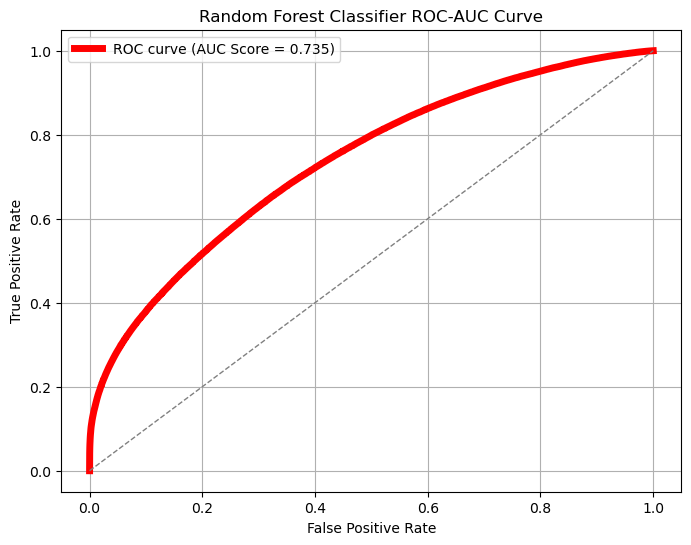

In [246]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='red', lw=5, label=f'ROC curve (AUC Score = {rocauc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest Classifier ROC-AUC Curve")
plt.legend(loc='upper left')
plt.grid(alpha=1.0)
plt.show()


In [247]:
#RANDOM FOREST CLASSIFICATION MODEL -- VISUALIZATION

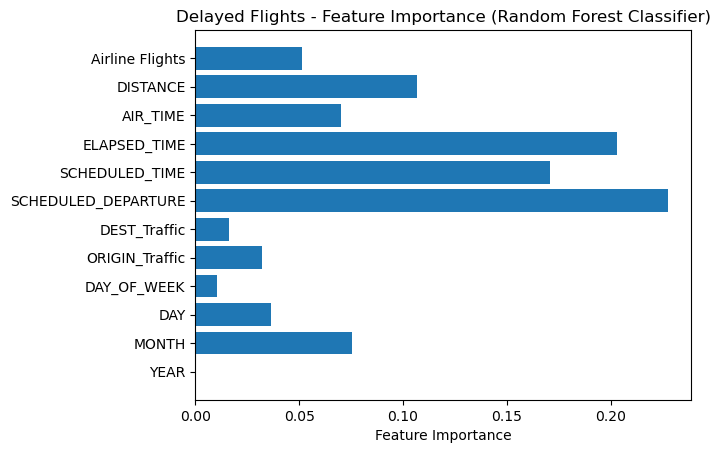

In [248]:
importantfeatures = random_forest.feature_importances_

plt.barh(X.columns, importantfeatures)
plt.xlabel('Feature Importance')
plt.title('Delayed Flights - Feature Importance (Random Forest Classifier)')
plt.show()

In [249]:
#LOGISTIC REGRESSION CLASSIFICATION MODEL -- TRAINING

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=500, C=1.0, n_jobs=-1, verbose=1, random_state=42)
log_reg.fit(X_train, y_train)

# Our Logistic Regression model was initiated, with the regularization paramter 'C' set to the default of '1.0'.
# In order to simultaneously apply the L1 (for feature selection) and L2 (for multicollinearity) penalties to the model, the penalty parameter was set to 'elasticnet'. 
# The required solver for the elastic net penalty is 'saga'.
# The L1 ratio was set to 0.5 to balance the L1 and L2 penalties.
# The model was subsequently trained using the 80% training subset.

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


convergence after 13 epochs took 72 seconds


LogisticRegression(l1_ratio=0.5, max_iter=500, n_jobs=-1, penalty='elasticnet',
                   random_state=42, solver='saga', verbose=1)

In [250]:
y_pred_log = log_reg.predict(X_test)

y_prob_log = log_reg.predict_proba(X_test)[:, 1]

# After training the logistic regression model, predictions were made on the 20% test subset.
# The probability of predicting the delayed class across classification thresholds was also generated.

In [251]:
#LOGISTIC REGRESSION CLASSIFICATION MODEL -- EVALUATION

In [252]:
accuracy = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 84.87%


In [253]:
from sklearn.metrics import roc_auc_score

rocauc = roc_auc_score(y_test, y_prob_log)

fpr_log, tpr_log, _ = roc_curve(y_test,y_prob_log)

print("ROC-AUC Score:", rocauc)

ROC-AUC Score: 0.71803338098557


In [254]:
# The ROC-AUC score of roughly 0.72 indicates that the model is relatively good at differentiating the two classes as it is above 0.5.

In [255]:
#LOGISTIC REGRESSION CLASSIFICATION MODEL -- VISUALIZATION

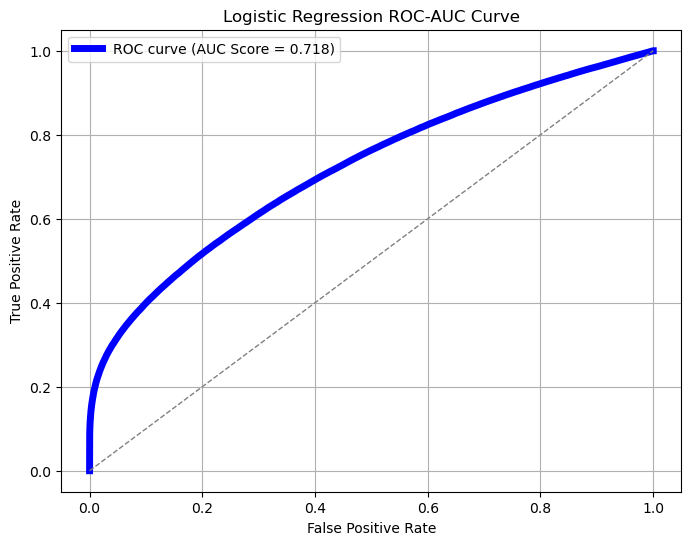

In [256]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, color='blue', lw=5, label=f'ROC curve (AUC Score = {rocauc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC-AUC Curve")
plt.legend(loc='upper left')
plt.grid(alpha=1.0)
plt.show()


In [257]:
featureimportance_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": log_reg.coef_[0]})

featureimportance_df["Coefficient Absolute Value"] = featureimportance_df["Coefficient"].abs()
featureimportance_df = featureimportance_df.sort_values("Coefficient Absolute Value")


featureimportance_df.head(15)

# To visualize feature importance values, the coefficient of each feature used to train the model was first derived, and the absolute value of the coefficient was used for the purpose of ranking their importance.

,Feature,Coefficient,Coefficient Absolute Value
0,YEAR,0.000000,0.000000
2,DAY,-0.013939,0.013939
3,DAY_OF_WEEK,-0.026213,0.026213
5,DEST_Traffic,0.033537,0.033537
4,ORIGIN_Traffic,0.070544,0.070544
1,MONTH,-0.082200,0.082200
11,Airline Flights,0.083375,0.083375
10,DISTANCE,-0.228744,0.228744
6,SCHEDULED_DEPARTURE,0.427320,0.427320
9,AIR_TIME,-1.229663,1.229663


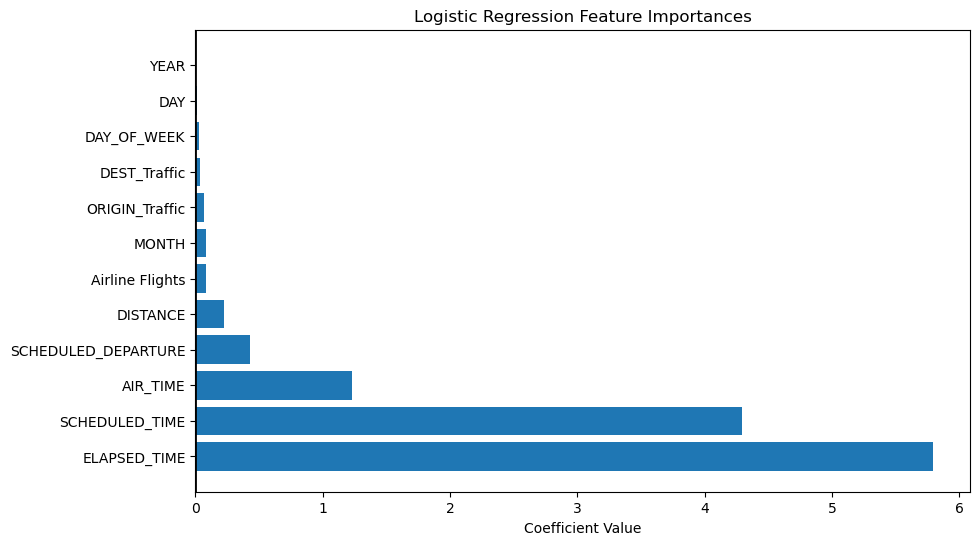

In [258]:
plt.figure(figsize=(10,6))
plt.barh(featureimportance_df["Feature"], featureimportance_df["Coefficient Absolute Value"])
plt.axvline(0, color="black", linewidth=2)
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [259]:
# The horizontal bar plots used to illustrate feature importances enable us to understand which features are most influential when forecasting flight delays.
# With regards to our Random Forest Classification model, the principal features that contribute to delays are the Scheduled Departure, Elapsed Time, and Scheduled Time.
# For our Logistic Regression model, the most important features were Elapsed Time, Scheduled Time, and Air Time.
#

In [260]:
# Both classification models displayed relatively high accuracy in predicting whether flights would be delayed or on-time, with the Random Forest Classifier exhbiting 82.8% accuracy and the Logistic Regression model exhibiting a marginally higher accuracy of 84.9%.
# These models could be used to proactively identify flights that are likely to be delayed so that passengers can be well-informed, and crew and airddfcrafts can be reallocated to offset the potential delays.
# Furthermore, the prediction probabilities generated by the models could be used to specifically focus on those flights with a predicted delay probability of 75% or more so that these flights can be prioritized when reallocating resources.
# Despite these benefits to business decision making, one shortcoming is the low Recall that the Random Forest Classifier displayed when detecting delayed flights. This warrants revisions to the classification threshold to ensure that potential delays are not missed or under detected.